# Bidirectional spatial radiometric coefficients — clean workflow

This notebook is a cleaned, focused successor to
`imagery_derive_spatial_coefficients.ipynb`.

## Scope

For every **flight date × DLS mode × source/destination direction × band**, it:

1. loads the saved homogeneous overlap patches;
2. fits a robust affine transformation;
3. runs a patch-cluster bootstrap;
4. saves coefficient, uncertainty, QA, and round-trip consistency tables;
5. plots:
   - gain by band;
   - offset by band;
   - gain versus offset;
   - round-trip gain and offset errors.

The fitted convention is always:

\[
\text{destination} = \text{gain}\times\text{source}+\text{offset}.
\]

Directions are fitted **independently**:

- Brunswick → Westham
- Westham → Brunswick

The reverse fit is not obtained merely by algebraically inverting the forward
fit, because robust regression is directional and the two independent fits
provide a useful round-trip QA check.

## Prerequisite

Run the registration and homogeneous-patch extraction stages of the original
spatial notebook first. This notebook expects one saved GeoJSON patch file for
each date and DLS mode.

## Review changes incorporated

- Spatial fitting is separated from the unrelated absolute-panel calibration.
- Both spatial directions are explicit data dimensions.
- Predictor and response values are robustly standardized before Huber fitting.
  This addresses the unstable/near-zero bootstrap fits visible for some bands
  in the earlier notebook.
- Bootstrap resampling is performed at the patch level and shared across bands
  within each case, preserving cross-band dependence.
- Bootstrap success rate and model-iteration diagnostics are retained.
- Output rows carry an explicit equation, source site, destination site,
  direction, date, mode, band, units, method, and uncertainty.
- Round-trip composition is calculated:
  `B → W → B` should have gain near 1 and offset near 0.
- CSV, Parquet, JSON, manifest, and publication-ready figures are written.

In [2]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import r2_score

plt.style.use("default")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## 1. Configuration

In [3]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()

DATES = ["2026-05-04", "2026-05-18"]
DLS_MODES = ["DLS", "NoDLS"]

INPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imagery"
    / "radiometry_eval"
    / "spatial_absolute_calibration"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imagery"
    / "radiometry_eval"
    / "bidirectional_spatial_coefficients"
)

FIGURE_DIR = OUTPUT_DIR / "figures"

FIT_METHOD = "huber"       # "huber" or "ols"
HUBER_EPSILON = 1.35
MIN_PATCHES_PER_BAND = 12
N_BOOTSTRAP = 1000
RANDOM_SEED = 872341

SAVE_OUTPUTS = True
SAVE_PARQUET = True
SAVE_PDF_FIGURES = True

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Input directory:", INPUT_DIR)
print("Output directory:", OUTPUT_DIR)

Project root: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm
Input directory: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/spatial_absolute_calibration
Output directory: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/bidirectional_spatial_coefficients


In [22]:
# ============================================================
# Result-cache configuration
# ============================================================

# False: load compatible saved results when available.
# True: ignore the cache, refit all cases, rerun the bootstrap,
#       and replace the cache.
FORCE_REFIT = False

# Set to False to disable loading and writing the Pickle cache.
USE_RESULT_CACHE = True

# Increase this if the cache structure changes in a future
# version of the notebook.
CACHE_VERSION = 1

CACHE_DIR = OUTPUT_DIR / "_result_cache"

COEFFICIENT_CACHE_PATH = CACHE_DIR / "spatial_coefficients.pkl"
BOOTSTRAP_CACHE_PATH = CACHE_DIR / "spatial_bootstrap.pkl"
CASE_QA_CACHE_PATH = CACHE_DIR / "case_qa.pkl"
CACHE_METADATA_PATH = CACHE_DIR / "cache_metadata.json"

if USE_RESULT_CACHE:
    CACHE_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )


## 2. Band and direction metadata

In [ ]:
SOURCE_BAND_NUMBERS = list(range(1, 12))
SOURCE_BAND_NAMES = [
    "B1", "B2", "B3", "B4", "PAN",
    "B5", "B6", "B7", "B8", "B9", "B10",
]

SPECTRAL_WAVELENGTHS_NM = {
    "B1": 444,
    "B2": 475,
    "B3": 531,
    "B4": 560,
    "B5": 650,
    "B6": 668,
    "B7": 705,
    "B8": 717,
    "B9": 740,
    "B10": 842,
}

BAND_METADATA = pd.DataFrame({
    "source_band": SOURCE_BAND_NUMBERS,
    "band_name": SOURCE_BAND_NAMES,
})
BAND_METADATA["band_index"] = np.arange(len(BAND_METADATA))
BAND_METADATA["wavelength_nm"] = (
    BAND_METADATA["band_name"].map(SPECTRAL_WAVELENGTHS_NM)
)
BAND_METADATA["is_pan"] = BAND_METADATA["band_name"].eq("PAN")

DIRECTIONS = {
    "brunswick_to_westham": {
        "source_site": "brunswick",
        "destination_site": "westham",
        "source_prefix": "br",
        "destination_prefix": "west",
        "label": "Brunswick → Westham",
    },
    "westham_to_brunswick": {
        "source_site": "westham",
        "destination_site": "brunswick",
        "source_prefix": "west",
        "destination_prefix": "br",
        "label": "Westham → Brunswick",
    },
}

display(BAND_METADATA)
display(pd.DataFrame(DIRECTIONS).T)


,source_band,band_name,band_index,wavelength_nm,is_pan
0,1,B1,0,444.0,False
1,2,B2,1,475.0,False
2,3,B3,2,531.0,False
3,4,B4,3,560.0,False
4,5,PAN,4,NaN,True
5,6,B5,5,650.0,False
6,7,B6,6,668.0,False
7,8,B7,7,705.0,False
8,9,B8,8,717.0,False
9,10,B9,9,740.0,False


,source_site,destination_site,source_prefix,destination_prefix,label
brunswick_to_westham,brunswick,westham,br,west,Brunswick → Westham
westham_to_brunswick,westham,brunswick,west,br,Westham → Brunswick


## 3. Input patch checkpoints

In [5]:
def case_stem(flight_date, dls_mode):
    return f"{flight_date}_{dls_mode}".replace("-", "")


def patch_path(flight_date, dls_mode):
    return (
        INPUT_DIR
        / f"{case_stem(flight_date, dls_mode)}"
        "_homogeneous_overlap_patches.geojson"
    )


input_registry = pd.DataFrame([
    {
        "flight_date": flight_date,
        "dls_mode": dls_mode,
        "patch_path": patch_path(flight_date, dls_mode),
        "exists": patch_path(flight_date, dls_mode).exists(),
    }
    for flight_date in DATES
    for dls_mode in DLS_MODES
])

display(input_registry)

missing = input_registry.loc[~input_registry["exists"], "patch_path"].tolist()
if missing:
    warnings.warn(
        "Some patch checkpoints are missing. Run the original registration/"
        "patch-extraction stages first:\n- "
        + "\n- ".join(map(str, missing))
    )

,flight_date,dls_mode,patch_path,exists
0,2026-05-04,DLS,/home/coder/jchampion/Biofilm_LEG13553/confide...,True
1,2026-05-04,NoDLS,/home/coder/jchampion/Biofilm_LEG13553/confide...,True
2,2026-05-18,DLS,/home/coder/jchampion/Biofilm_LEG13553/confide...,True
3,2026-05-18,NoDLS,/home/coder/jchampion/Biofilm_LEG13553/confide...,True


## 4. Robust affine fitting

In [6]:
def robust_scale(values):
    values = np.asarray(values, dtype=float)
    q25, q75 = np.nanquantile(values, [0.25, 0.75])
    scale = (q75 - q25) / 1.349

    if not np.isfinite(scale) or scale <= 0:
        scale = np.nanstd(values, ddof=1)
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0

    return float(scale)


def fit_affine(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < MIN_PATCHES_PER_BAND:
        raise ValueError(f"Only {len(x)} valid patches.")

    # Robust standardization materially improves Huber numerical stability
    # for reflectance values whose magnitude and dynamic range are small.
    x_center = float(np.nanmedian(x))
    y_center = float(np.nanmedian(y))
    x_scale = robust_scale(x)
    y_scale = robust_scale(y)

    x_scaled = (x - x_center) / x_scale
    y_scaled = (y - y_center) / y_scale

    if FIT_METHOD == "huber":
        model = HuberRegressor(
            epsilon=HUBER_EPSILON,
            alpha=0.0,
            fit_intercept=True,
            max_iter=2000,
            tol=1e-8,
        )
    elif FIT_METHOD == "ols":
        model = LinearRegression()
    else:
        raise ValueError(f"Unknown FIT_METHOD: {FIT_METHOD}")

    model.fit(x_scaled[:, None], y_scaled)

    gain = float(model.coef_[0] * y_scale / x_scale)
    offset = float(
        y_center
        + y_scale * model.intercept_
        - gain * x_center
    )

    predicted = gain * x + offset
    residual = y - predicted

    return {
        "gain": gain,
        "offset": offset,
        "r2": float(r2_score(y, predicted)),
        "rmse": float(np.sqrt(np.mean(residual ** 2))),
        "mae": float(np.mean(np.abs(residual))),
        "bias": float(np.mean(residual)),
        "n": int(len(x)),
        "x_center": x_center,
        "x_scale": x_scale,
        "y_center": y_center,
        "y_scale": y_scale,
        "model_iterations": int(getattr(model, "n_iter_", 1)),
    }

## 5. Case validation and deterministic bootstrap seeds

In [7]:
def required_patch_columns():
    columns = []
    for band_name in SOURCE_BAND_NAMES:
        columns.extend([
            f"br_{band_name}_median",
            f"west_{band_name}_median",
        ])
    return columns


def validate_patches(patches, flight_date, dls_mode):
    if patches.empty:
        raise ValueError(f"Empty patch table: {flight_date} | {dls_mode}")

    missing_columns = sorted(
        set(required_patch_columns()) - set(patches.columns)
    )
    if missing_columns:
        raise ValueError(
            f"Missing patch columns for {flight_date} | {dls_mode}: "
            f"{missing_columns}"
        )

    if len(patches) < MIN_PATCHES_PER_BAND:
        raise ValueError(
            f"Only {len(patches)} patches for {flight_date} | {dls_mode}"
        )


def stable_case_seed(flight_date, dls_mode):
    token = f"{RANDOM_SEED}|{flight_date}|{dls_mode}".encode("utf-8")
    digest = hashlib.blake2b(token, digest_size=8).digest()
    return int.from_bytes(digest, "little") % (2**32 - 1)

## 6. Fit both directions and bootstrap at patch level

In [8]:
def fit_case(patches, *, flight_date, dls_mode):
    validate_patches(patches, flight_date, dls_mode)

    coefficient_records = []
    bootstrap_records = []

    # Point estimates.
    for direction, spec in DIRECTIONS.items():
        for band_name in SOURCE_BAND_NAMES:
            source_column = f"{spec['source_prefix']}_{band_name}_median"
            destination_column = (
                f"{spec['destination_prefix']}_{band_name}_median"
            )

            fit = fit_affine(
                patches[source_column].to_numpy(),
                patches[destination_column].to_numpy(),
            )

            coefficient_records.append({
                "transform_name": (
                    f"{direction}_{flight_date}_{dls_mode}"
                ),
                "direction": direction,
                "direction_label": spec["label"],
                "source_site": spec["source_site"],
                "destination_site": spec["destination_site"],
                "equation": "destination = gain * source + offset",
                "flight_date": flight_date,
                "dls_mode": dls_mode,
                "band_name": band_name,
                "value_units": "raster_native_or_scaled_reflectance",
                "fit_method": FIT_METHOD,
                **fit,
            })

    # Shared patch-cluster resamples preserve cross-band dependence.
    rng = np.random.default_rng(stable_case_seed(flight_date, dls_mode))
    n_patches = len(patches)

    for iteration in range(N_BOOTSTRAP):
        sampled_index = rng.integers(0, n_patches, size=n_patches)
        sampled = patches.iloc[sampled_index]

        for direction, spec in DIRECTIONS.items():
            for band_name in SOURCE_BAND_NAMES:
                source_column = (
                    f"{spec['source_prefix']}_{band_name}_median"
                )
                destination_column = (
                    f"{spec['destination_prefix']}_{band_name}_median"
                )

                try:
                    fit = fit_affine(
                        sampled[source_column].to_numpy(),
                        sampled[destination_column].to_numpy(),
                    )
                    bootstrap_records.append({
                        "flight_date": flight_date,
                        "dls_mode": dls_mode,
                        "direction": direction,
                        "band_name": band_name,
                        "bootstrap_iteration": iteration,
                        "gain": fit["gain"],
                        "offset": fit["offset"],
                        "r2": fit["r2"],
                        "rmse": fit["rmse"],
                    })
                except Exception:
                    # Failures are counted through bootstrap_success_fraction.
                    continue

    coefficients = pd.DataFrame(coefficient_records)
    bootstrap = pd.DataFrame(bootstrap_records)

    grouping = ["flight_date", "dls_mode", "direction", "band_name"]
    uncertainty = (
        bootstrap.groupby(grouping, observed=True)
        .agg(
            bootstrap_success_count=("bootstrap_iteration", "nunique"),
            gain_se=("gain", "std"),
            gain_ci_low=("gain", lambda x: x.quantile(0.025)),
            gain_ci_high=("gain", lambda x: x.quantile(0.975)),
            offset_se=("offset", "std"),
            offset_ci_low=("offset", lambda x: x.quantile(0.025)),
            offset_ci_high=("offset", lambda x: x.quantile(0.975)),
        )
        .reset_index()
    )
    uncertainty["bootstrap_success_fraction"] = (
        uncertainty["bootstrap_success_count"] / N_BOOTSTRAP
    )

    coefficients = coefficients.merge(
        uncertainty,
        on=grouping,
        how="left",
        validate="one_to_one",
    )

    coefficients = coefficients.merge(
        BAND_METADATA,
        on="band_name",
        how="left",
        validate="many_to_one",
    )

    bootstrap = bootstrap.merge(
        BAND_METADATA[["band_name", "source_band", "band_index",
                       "wavelength_nm", "is_pan"]],
        on="band_name",
        how="left",
        validate="many_to_one",
    )

    return coefficients, bootstrap

## 7.0 cache-helper

In [23]:
# ============================================================
# Result-cache helper functions
# ============================================================


def patch_file_fingerprint():
    """
    Record enough information to detect changes to the
    homogeneous-patch input files.
    """
    records = []

    for flight_date in DATES:
        for dls_mode in DLS_MODES:
            path = patch_path(
                flight_date,
                dls_mode,
            )

            record = {
                "flight_date": flight_date,
                "dls_mode": dls_mode,
                "path": str(path),
                "exists": path.exists(),
            }

            if path.exists():
                statistics = path.stat()

                record["size_bytes"] = statistics.st_size
                record["modified_time_ns"] = statistics.st_mtime_ns

            records.append(record)

    return records


def current_cache_signature():
    """
    Configuration and input-file signature for cache
    compatibility checks.
    """
    return {
        "cache_version": CACHE_VERSION,
        "input_dir": str(INPUT_DIR),
        "dates": list(DATES),
        "dls_modes": list(DLS_MODES),
        "directions": list(DIRECTIONS),
        "bands": list(SOURCE_BAND_NAMES),
        "fit_method": FIT_METHOD,
        "huber_epsilon": (HUBER_EPSILON if FIT_METHOD == "huber" else None),
        "minimum_patches_per_band": (MIN_PATCHES_PER_BAND),
        "bootstrap_iterations": N_BOOTSTRAP,
        "random_seed": RANDOM_SEED,
        "patch_files": patch_file_fingerprint(),
    }


def result_cache_files_exist():
    required_paths = [
        COEFFICIENT_CACHE_PATH,
        BOOTSTRAP_CACHE_PATH,
        CASE_QA_CACHE_PATH,
        CACHE_METADATA_PATH,
    ]

    return all(path.exists() for path in required_paths)


def atomic_pickle_save(frame, path):
    """
    Write to a temporary file before replacing the existing
    cache file, reducing the chance of a partial cache.
    """
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    frame.to_pickle(temporary_path)
    temporary_path.replace(path)


def save_result_cache(
    coefficient_table,
    bootstrap_table,
    case_qa_table,
):
    if not USE_RESULT_CACHE:
        return

    CACHE_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    tables = {
        "spatial_coefficients": coefficient_table,
        "spatial_bootstrap": bootstrap_table,
        "case_qa": case_qa_table,
    }

    for table_name, frame in tables.items():
        if not isinstance(frame, pd.DataFrame):
            raise TypeError(f"{table_name} is not a pandas DataFrame.")

        if frame.empty:
            raise ValueError(f"{table_name} is empty; cache not written.")

    atomic_pickle_save(
        coefficient_table,
        COEFFICIENT_CACHE_PATH,
    )
    atomic_pickle_save(
        bootstrap_table,
        BOOTSTRAP_CACHE_PATH,
    )
    atomic_pickle_save(
        case_qa_table,
        CASE_QA_CACHE_PATH,
    )

    metadata = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "signature": current_cache_signature(),
        "row_counts": {
            "spatial_coefficients": len(coefficient_table),
            "spatial_bootstrap": len(bootstrap_table),
            "case_qa": len(case_qa_table),
        },
    }

    temporary_metadata_path = CACHE_METADATA_PATH.with_suffix(".json.tmp")

    with open(
        temporary_metadata_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            metadata,
            file,
            indent=2,
        )

    temporary_metadata_path.replace(CACHE_METADATA_PATH)

    print("Result cache saved:")
    print(" ", CACHE_DIR)


def load_result_cache():
    if not result_cache_files_exist():
        raise FileNotFoundError("One or more result-cache files are missing.")

    with open(
        CACHE_METADATA_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        metadata = json.load(file)

    saved_signature = metadata.get("signature")
    expected_signature = current_cache_signature()

    if saved_signature != expected_signature:
        raise ValueError(
            "The saved cache is not compatible with the "
            "current notebook configuration or patch files."
        )

    coefficient_table = pd.read_pickle(COEFFICIENT_CACHE_PATH)
    bootstrap_table = pd.read_pickle(BOOTSTRAP_CACHE_PATH)
    case_qa_table = pd.read_pickle(CASE_QA_CACHE_PATH)

    required_coefficient_columns = {
        "flight_date",
        "dls_mode",
        "direction",
        "band_name",
        "band_index",
        "gain",
        "offset",
    }

    missing_columns = required_coefficient_columns - set(coefficient_table.columns)

    if missing_columns:
        raise ValueError(
            f"The coefficient cache is missing columns: {sorted(missing_columns)}"
        )

    if coefficient_table.empty or bootstrap_table.empty or case_qa_table.empty:
        raise ValueError("At least one loaded cache table is empty.")

    print("Compatible result cache loaded.")
    print(
        "  Coefficient rows:",
        f"{len(coefficient_table):,}",
    )
    print(
        "  Bootstrap rows:",
        f"{len(bootstrap_table):,}",
    )
    print(
        "  Case-QA rows:",
        f"{len(case_qa_table):,}",
    )
    print(
        "  Cache created:",
        metadata.get("created_utc"),
    )

    return (
        coefficient_table,
        bootstrap_table,
        case_qa_table,
    )


## 7. Run all four date × mode cases

In [24]:
# ============================================================
# Load saved results or compute all date × DLS cases
# ============================================================

loaded_from_cache = False

if USE_RESULT_CACHE and not FORCE_REFIT:
    try:
        (
            spatial_coefficients,
            spatial_bootstrap,
            case_qa,
        ) = load_result_cache()

        loaded_from_cache = True

    except FileNotFoundError as error:
        print("No complete result cache was found.")
        print("Reason:", error)
        print("The coefficients and bootstrap will be computed.")

    except ValueError as error:
        print("The existing result cache cannot be used.")
        print("Reason:", error)
        print("The coefficients and bootstrap will be recomputed.")


if not loaded_from_cache:
    all_coefficients = []
    all_bootstrap = []
    case_qa_records = []

    for flight_date in DATES:
        for dls_mode in DLS_MODES:
            path = patch_path(
                flight_date,
                dls_mode,
            )

            print("=" * 72)
            print(f"Case: {flight_date} | {dls_mode}")
            print("Patch file:", path)

            if not path.exists():
                print("SKIPPED: patch checkpoint does not exist.")
                continue

            patches = gpd.read_file(path)

            validate_patches(
                patches,
                flight_date,
                dls_mode,
            )

            coefficients, bootstrap = fit_case(
                patches,
                flight_date=flight_date,
                dls_mode=dls_mode,
            )

            all_coefficients.append(coefficients)
            all_bootstrap.append(bootstrap)

            case_qa_records.append(
                {
                    "flight_date": flight_date,
                    "dls_mode": dls_mode,
                    "patch_count": len(patches),
                    "coefficient_rows": len(coefficients),
                    "bootstrap_rows": len(bootstrap),
                    "expected_bootstrap_rows": (
                        N_BOOTSTRAP * len(DIRECTIONS) * len(SOURCE_BAND_NAMES)
                    ),
                }
            )

            print(
                f"patches={len(patches):,}; "
                f"coefficients={len(coefficients):,}; "
                f"bootstrap rows={len(bootstrap):,}"
            )

    if not all_coefficients:
        raise RuntimeError(
            "No cases were fitted. Check INPUT_DIR and the patch checkpoints."
        )

    spatial_coefficients = pd.concat(
        all_coefficients,
        ignore_index=True,
    )

    spatial_bootstrap = pd.concat(
        all_bootstrap,
        ignore_index=True,
    )

    case_qa = pd.DataFrame(case_qa_records)

    # Save immediately after the expensive computation.
    save_result_cache(
        spatial_coefficients,
        spatial_bootstrap,
        case_qa,
    )


# Apply consistent ordering whether the data were loaded
# or newly computed.
sort_columns = [
    "flight_date",
    "dls_mode",
    "direction",
    "band_index",
]

spatial_coefficients = spatial_coefficients.sort_values(sort_columns).reset_index(
    drop=True
)

spatial_bootstrap = spatial_bootstrap.sort_values(
    [
        "flight_date",
        "dls_mode",
        "direction",
        "band_index",
        "bootstrap_iteration",
    ]
).reset_index(drop=True)

case_qa = case_qa.sort_values(
    [
        "flight_date",
        "dls_mode",
    ]
).reset_index(drop=True)

if loaded_from_cache:
    print("\nUsing saved fit and bootstrap results. No fitting was performed.")
else:
    print("\nNew fit and bootstrap results were computed and cached.")

display(case_qa)
display(spatial_coefficients)


Compatible result cache loaded.
  Coefficient rows: 88
  Bootstrap rows: 88,000
  Case-QA rows: 4
  Cache created: 2026-09-24T01:46:00.324729+00:00

Using saved fit and bootstrap results. No fitting was performed.


,flight_date,dls_mode,patch_count,coefficient_rows,bootstrap_rows,expected_bootstrap_rows
0,2026-05-04,DLS,500,22,22000,22000
1,2026-05-04,NoDLS,500,22,22000,22000
2,2026-05-18,DLS,500,22,22000,22000
3,2026-05-18,NoDLS,500,22,22000,22000


,transform_name,direction,direction_label,source_site,destination_site,equation,flight_date,dls_mode,band_name,value_units,fit_method,gain,offset,r2,rmse,mae,bias,n,x_center,x_scale,y_center,y_scale,model_iterations,bootstrap_success_count,gain_se,gain_ci_low,gain_ci_high,offset_se,offset_ci_low,offset_ci_high,bootstrap_success_fraction,source_band,band_index,wavelength_nm,is_pan
0,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B1,raster_native_or_scaled_reflectance,huber,2.114857,-0.006202,0.932768,0.001274,0.000825,0.000011,500,0.010162,0.002540,0.015113,0.005148,12,1000,0.037184,2.044310,2.187889,0.000378,-0.006942,-0.005480,1.0,1,0,444.0,False
1,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B2,raster_native_or_scaled_reflectance,huber,2.309573,-0.008369,0.920367,0.001297,0.000852,-0.000015,500,0.011190,0.001854,0.017271,0.004320,11,1000,0.038517,2.223228,2.370699,0.000431,-0.009045,-0.007410,1.0,2,1,475.0,False
2,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B3,raster_native_or_scaled_reflectance,huber,2.474582,-0.012530,0.848961,0.001766,0.001248,-0.000041,500,0.014827,0.001918,0.023369,0.003038,10,1000,0.050235,2.375975,2.573061,0.000717,-0.013961,-0.011102,1.0,3,2,531.0,False
3,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B4,raster_native_or_scaled_reflectance,huber,2.524686,-0.013741,0.798781,0.001992,0.001421,-0.000041,500,0.015983,0.001688,0.026030,0.002942,10,1000,0.076187,2.344534,2.640773,0.001180,-0.015556,-0.010983,1.0,4,3,560.0,False
4,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,PAN,raster_native_or_scaled_reflectance,huber,2.318646,-0.008181,0.952628,0.001560,0.001054,-0.000003,500,0.011509,0.003250,0.018265,0.007381,13,1000,0.040966,2.248004,2.405913,0.000475,-0.009179,-0.007365,1.0,5,4,NaN,True
5,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B5,raster_native_or_scaled_reflectance,huber,2.612838,-0.012723,0.884793,0.002044,0.001417,-0.000223,500,0.014528,0.002466,0.024277,0.005295,12,1000,0.035516,2.544317,2.682466,0.000493,-0.013700,-0.011760,1.0,6,5,650.0,False
6,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B6,raster_native_or_scaled_reflectance,huber,2.624251,-0.011473,0.896295,0.001735,0.001170,-0.000160,500,0.013039,0.002150,0.022241,0.005447,10,1000,0.034193,2.558526,2.693074,0.000426,-0.012312,-0.010651,1.0,7,6,668.0,False
7,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B7,raster_native_or_scaled_reflectance,huber,2.437036,-0.008783,0.982242,0.001339,0.000904,-0.000021,500,0.011141,0.004576,0.018452,0.011683,15,1000,0.018550,2.400146,2.471633,0.000214,-0.009187,-0.008358,1.0,8,7,705.0,False
8,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B8,raster_native_or_scaled_reflectance,huber,2.249519,-0.005964,0.988696,0.001286,0.000841,-0.000045,500,0.008988,0.006650,0.014462,0.014881,15,1000,0.013057,2.224313,2.276031,0.000123,-0.006207,-0.005721,1.0,9,8,717.0,False
9,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B9,raster_native_or_scaled_reflectance,huber,2.118759,-0.002110,0.994405,0.001148,0.000675,-0.000008,500,

## 8. Validation

In [10]:
key_columns = [
    "flight_date", "dls_mode", "direction", "band_name",
]

if spatial_coefficients.duplicated(key_columns).any():
    duplicates = spatial_coefficients.loc[
        spatial_coefficients.duplicated(key_columns, keep=False),
        key_columns,
    ]
    raise ValueError(f"Duplicate coefficient keys:\n{duplicates}")

expected_rows = (
    len(DATES)
    * len(DLS_MODES)
    * len(DIRECTIONS)
    * len(SOURCE_BAND_NAMES)
)

completed_cases = case_qa.shape[0]
expected_completed_rows = (
    completed_cases
    * len(DIRECTIONS)
    * len(SOURCE_BAND_NAMES)
)

if len(spatial_coefficients) != expected_completed_rows:
    raise ValueError(
        f"Unexpected coefficient count: {len(spatial_coefficients)}; "
        f"expected {expected_completed_rows} for completed cases."
    )

numeric_columns = [
    "gain", "offset", "r2", "rmse", "mae", "bias",
    "gain_ci_low", "gain_ci_high",
    "offset_ci_low", "offset_ci_high",
    "bootstrap_success_fraction",
]

nonfinite = ~np.isfinite(
    spatial_coefficients[numeric_columns].to_numpy(dtype=float)
)
if nonfinite.any():
    warnings.warn("Some coefficient or uncertainty values are non-finite.")

low_success = spatial_coefficients[
    spatial_coefficients["bootstrap_success_fraction"] < 0.95
]
if not low_success.empty:
    warnings.warn(
        f"{len(low_success)} rows have bootstrap success below 95%."
    )

print("Expected full coefficient rows:", expected_rows)
print("Completed coefficient rows:", len(spatial_coefficients))
display(low_success)

Expected full coefficient rows: 88
Completed coefficient rows: 88


,transform_name,direction,direction_label,source_site,destination_site,equation,flight_date,dls_mode,band_name,value_units,fit_method,gain,offset,r2,rmse,mae,bias,n,x_center,x_scale,y_center,y_scale,model_iterations,bootstrap_success_count,gain_se,gain_ci_low,gain_ci_high,offset_se,offset_ci_low,offset_ci_high,bootstrap_success_fraction,source_band,band_index,wavelength_nm,is_pan


## 9. Round-trip consistency

For independently fitted transformations:

\[
W = g_{BW} B + b_{BW}
\]

and

\[
B' = g_{WB} W + b_{WB},
\]

the composed transform is:

\[
B' = (g_{WB}g_{BW})B + (g_{WB}b_{BW}+b_{WB}).
\]

Ideal round-trip values are therefore gain = 1 and offset = 0.

In [11]:
forward = spatial_coefficients.loc[
    spatial_coefficients["direction"].eq("brunswick_to_westham")
].copy()

reverse = spatial_coefficients.loc[
    spatial_coefficients["direction"].eq("westham_to_brunswick")
].copy()

merge_keys = [
    "flight_date", "dls_mode", "band_name",
    "source_band", "band_index", "wavelength_nm", "is_pan",
]

round_trip = forward.merge(
    reverse,
    on=merge_keys,
    suffixes=("_bw", "_wb"),
    validate="one_to_one",
)

round_trip["round_trip_gain"] = (
    round_trip["gain_wb"] * round_trip["gain_bw"]
)
round_trip["round_trip_offset"] = (
    round_trip["gain_wb"] * round_trip["offset_bw"]
    + round_trip["offset_wb"]
)
round_trip["round_trip_gain_error"] = (
    round_trip["round_trip_gain"] - 1.0
)
round_trip["round_trip_offset_error"] = (
    round_trip["round_trip_offset"]
)
round_trip["algebraic_inverse_gain_from_bw"] = (
    1.0 / round_trip["gain_bw"]
)
round_trip["algebraic_inverse_offset_from_bw"] = (
    -round_trip["offset_bw"] / round_trip["gain_bw"]
)
round_trip["wb_gain_minus_algebraic_inverse"] = (
    round_trip["gain_wb"]
    - round_trip["algebraic_inverse_gain_from_bw"]
)
round_trip["wb_offset_minus_algebraic_inverse"] = (
    round_trip["offset_wb"]
    - round_trip["algebraic_inverse_offset_from_bw"]
)

display(round_trip)

,transform_name_bw,direction_bw,direction_label_bw,source_site_bw,destination_site_bw,equation_bw,flight_date,dls_mode,band_name,value_units_bw,fit_method_bw,gain_bw,offset_bw,r2_bw,rmse_bw,mae_bw,bias_bw,n_bw,x_center_bw,x_scale_bw,y_center_bw,y_scale_bw,model_iterations_bw,bootstrap_success_count_bw,gain_se_bw,gain_ci_low_bw,gain_ci_high_bw,offset_se_bw,offset_ci_low_bw,offset_ci_high_bw,bootstrap_success_fraction_bw,source_band,band_index,wavelength_nm,is_pan,transform_name_wb,direction_wb,direction_label_wb,source_site_wb,destination_site_wb,equation_wb,value_units_wb,fit_method_wb,gain_wb,offset_wb,r2_wb,rmse_wb,mae_wb,bias_wb,n_wb,x_center_wb,x_scale_wb,y_center_wb,y_scale_wb,model_iterations_wb,bootstrap_success_count_wb,gain_se_wb,gain_ci_low_wb,gain_ci_high_wb,offset_se_wb,offset_ci_low_wb,offset_ci_high_wb,bootstrap_success_fraction_wb,round_trip_gain,round_trip_offset,round_trip_gain_error,round_trip_offset_error,algebraic_inverse_gain_from_bw,algebraic_inverse_offset_from_bw,wb_gain_minus_algebraic_inverse,wb_offset_minus_algebraic_inverse
0,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B1,raster_native_or_scaled_reflectance,huber,2.114857,-0.006202,0.932768,0.001274,0.000825,0.000011,500,0.010162,0.002540,0.015113,0.005148,12,1000,0.037184,2.044310,2.187889,0.000378,-0.006942,-0.005480,1.0,1,0,444.0,False,westham_to_brunswick_2026-05-04_DLS,westham_to_brunswick,Westham → Brunswick,westham,brunswick,destination = gain * source + offset,raster_native_or_scaled_reflectance,huber,0.441664,0.003443,0.932240,0.000564,0.000379,0.000045,500,0.015113,0.005148,0.010162,0.002540,11,1000,0.007221,0.427949,0.456493,0.000112,0.003219,0.003664,1.0,0.934056,0.000704,-0.065944,0.000704,0.472845,0.002933,-0.031181,0.000511
1,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B2,raster_native_or_scaled_reflectance,huber,2.309573,-0.008369,0.920367,0.001297,0.000852,-0.000015,500,0.011190,0.001854,0.017271,0.004320,11,1000,0.038517,2.223228,2.370699,0.000431,-0.009045,-0.007410,1.0,2,1,475.0,False,westham_to_brunswick_2026-05-04_DLS,westham_to_brunswick,Westham → Brunswick,westham,brunswick,destination = gain * source + offset,raster_native_or_scaled_reflectance,huber,0.403932,0.004160,0.918943,0.000531,0.000358,0.000047,500,0.017271,0.004320,0.011190,0.001854,10,1000,0.007351,0.388379,0.417401,0.000129,0.003921,0.004429,1.0,0.932911,0.000780,-0.067089,0.000780,0.432981,0.003623,-0.029048,0.000537
2,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B3,raster_native_or_scaled_reflectance,huber,2.474582,-0.012530,0.848961,0.001766,0.001248,-0.000041,500,0.014827,0.001918,0.023369,0.003038,10,1000,0.050235,2.375975,2.573061,0.000717,-0.013961,-0.011102,1.0,3,2,531.0,False,westham_to_brunswick_2026-05-04_DLS,westham_to_brunswick,Westham → Brunswick,westham,brunswick,destination = gain * source + offset,raster_native_or_scaled_reflectance,huber,0.351953,0.006341,0.845675,0.000663,0.000472,0.000088,500,0.023369,0.003038,0.014827,0.001918,10,1000,0.007785,0.337475,0.368192,0.000183,0.005960,0.006680,1.0,0.870938,0.001931,-0.129062,0.001931,0.404109,0.005063,-0.052155,0.001278
3,brunswick_to_westham_2026-05-04_DLS,brunswick_to_westham,Brunswick → Westham,brunswick,westham,destination = gain * source + offset,2026-05-04,DLS,B4,raster_native_or_scaled_reflectance,huber,2.524686,-0.013741,0.798781,0.001992,0.001421,-0.000041,500,0.015983,0.001688,0.026030,0.002942,10,1000,0.076187,2.344534,2.640773,0.001180,-0.015556,-0.010983,1.0,4,3,560.0,False,westham_to_brunswick_2026-05-04_DLS,westham_to_brunswick,Westham → Brunswick,westham,brunswick,destination = gain * source + offset,raster_native_or_scaled_reflectance,huber,0.332476,0.007161,0.795087,0.000732,0.0

## 10. Save reusable coefficient data

In [12]:
def json_safe_records(frame):
    clean = frame.astype(object).where(pd.notna(frame), None)
    return clean.to_dict(orient="records")


manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "imagery_derive_bidirectional_spatial_coefficients_clean.ipynb",
    "coefficient_equation": "destination = gain * source + offset",
    "fit_method": FIT_METHOD,
    "huber_epsilon": HUBER_EPSILON if FIT_METHOD == "huber" else None,
    "bootstrap_iterations_requested": N_BOOTSTRAP,
    "bootstrap_unit": "homogeneous overlap patch",
    "dates": DATES,
    "dls_modes": DLS_MODES,
    "directions": DIRECTIONS,
    "bands": json_safe_records(BAND_METADATA),
    "coefficient_key": [
        "flight_date", "dls_mode", "direction", "band_name",
    ],
}

if SAVE_OUTPUTS:
    spatial_coefficients.to_csv(
        OUTPUT_DIR / "all_bidirectional_spatial_coefficients.csv",
        index=False,
    )
    spatial_bootstrap.to_csv(
        OUTPUT_DIR / "all_bidirectional_spatial_bootstrap.csv.gz",
        index=False,
        compression="gzip",
    )
    round_trip.to_csv(
        OUTPUT_DIR / "all_spatial_round_trip_diagnostics.csv",
        index=False,
    )
    case_qa.to_csv(
        OUTPUT_DIR / "case_fit_qa.csv",
        index=False,
    )

    if SAVE_PARQUET:
        try:
            spatial_coefficients.to_parquet(
                OUTPUT_DIR / "all_bidirectional_spatial_coefficients.parquet",
                index=False,
            )
            spatial_bootstrap.to_parquet(
                OUTPUT_DIR / "all_bidirectional_spatial_bootstrap.parquet",
                index=False,
            )
            round_trip.to_parquet(
                OUTPUT_DIR / "all_spatial_round_trip_diagnostics.parquet",
                index=False,
            )
        except ImportError:
            warnings.warn(
                "Parquet export skipped because pyarrow/fastparquet "
                "is unavailable."
            )

    with open(
        OUTPUT_DIR / "all_bidirectional_spatial_coefficients.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                "manifest": manifest,
                "coefficients": json_safe_records(spatial_coefficients),
            },
            file,
            indent=2,
        )

    with open(
        OUTPUT_DIR / "coefficient_manifest.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(manifest, file, indent=2)

    print("Saved outputs to:", OUTPUT_DIR)

Saved outputs to: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/bidirectional_spatial_coefficients


## 11. Plotting helpers

In [28]:
DATE_LABELS = {
    "2026-05-04": "May 4, 2026",
    "2026-05-18": "May 18, 2026",
}

DIRECTION_LABELS = {
    key: value["label"]
    for key, value in DIRECTIONS.items()
}

DLS_PALETTE = {
    "NoDLS": "#0072B2",
    "DLS": "#D55E00",
}


def save_figure(fig, stem):
    if not SAVE_OUTPUTS:
        return
    fig.savefig(
        FIGURE_DIR / f"{stem}.png",
        dpi=220,
        bbox_inches="tight",
    )
    if SAVE_PDF_FIGURES:
        fig.savefig(
            FIGURE_DIR / f"{stem}.pdf",
            bbox_inches="tight",
        )


def add_band_axis(ax):
    ax.set_xticks(range(len(SOURCE_BAND_NAMES)))
    ax.set_xticklabels(SOURCE_BAND_NAMES, rotation=45, ha="right")
    ax.set_xlabel("Band")

## 12. Gain and offset profiles

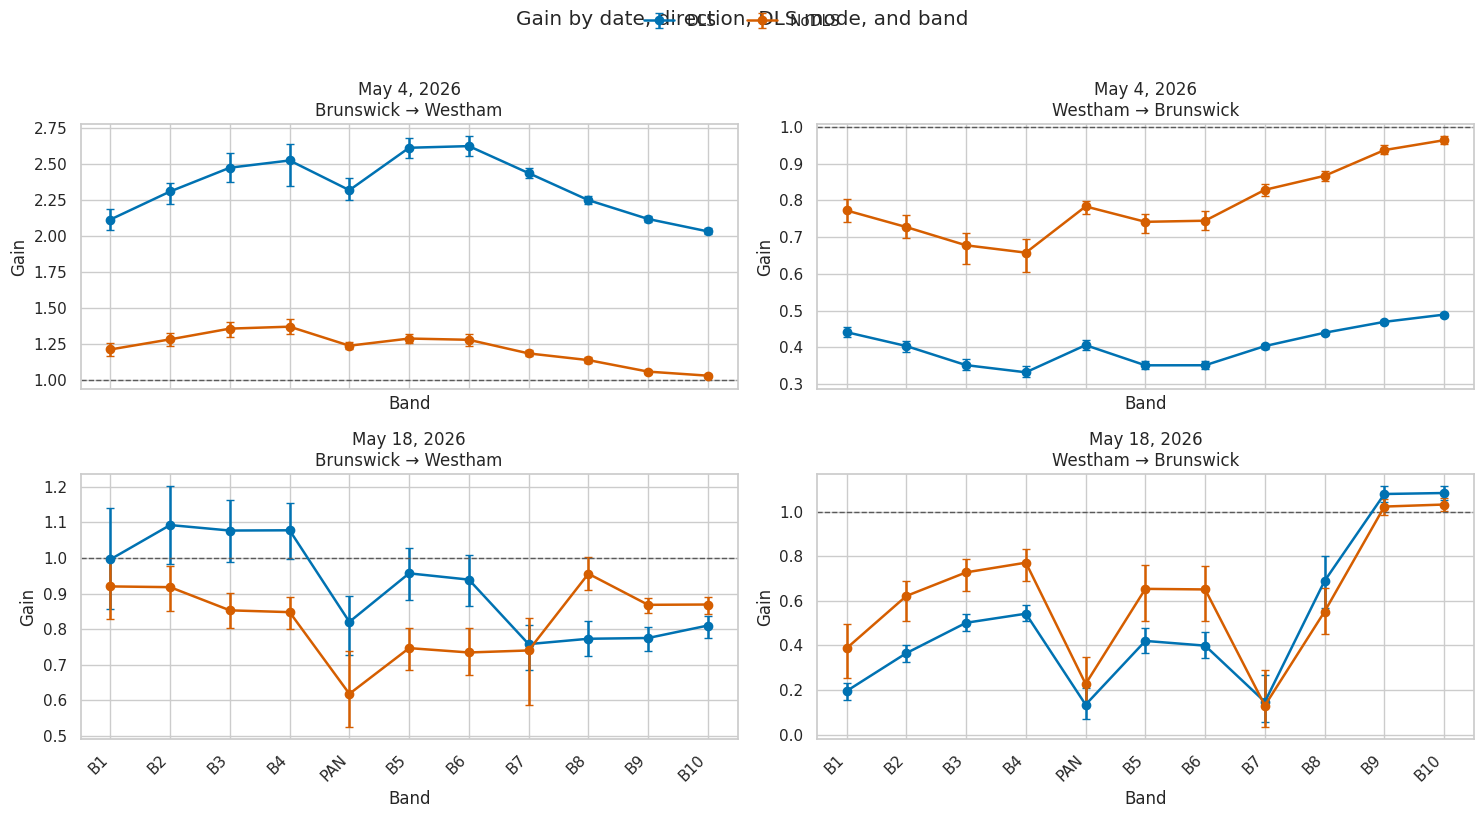

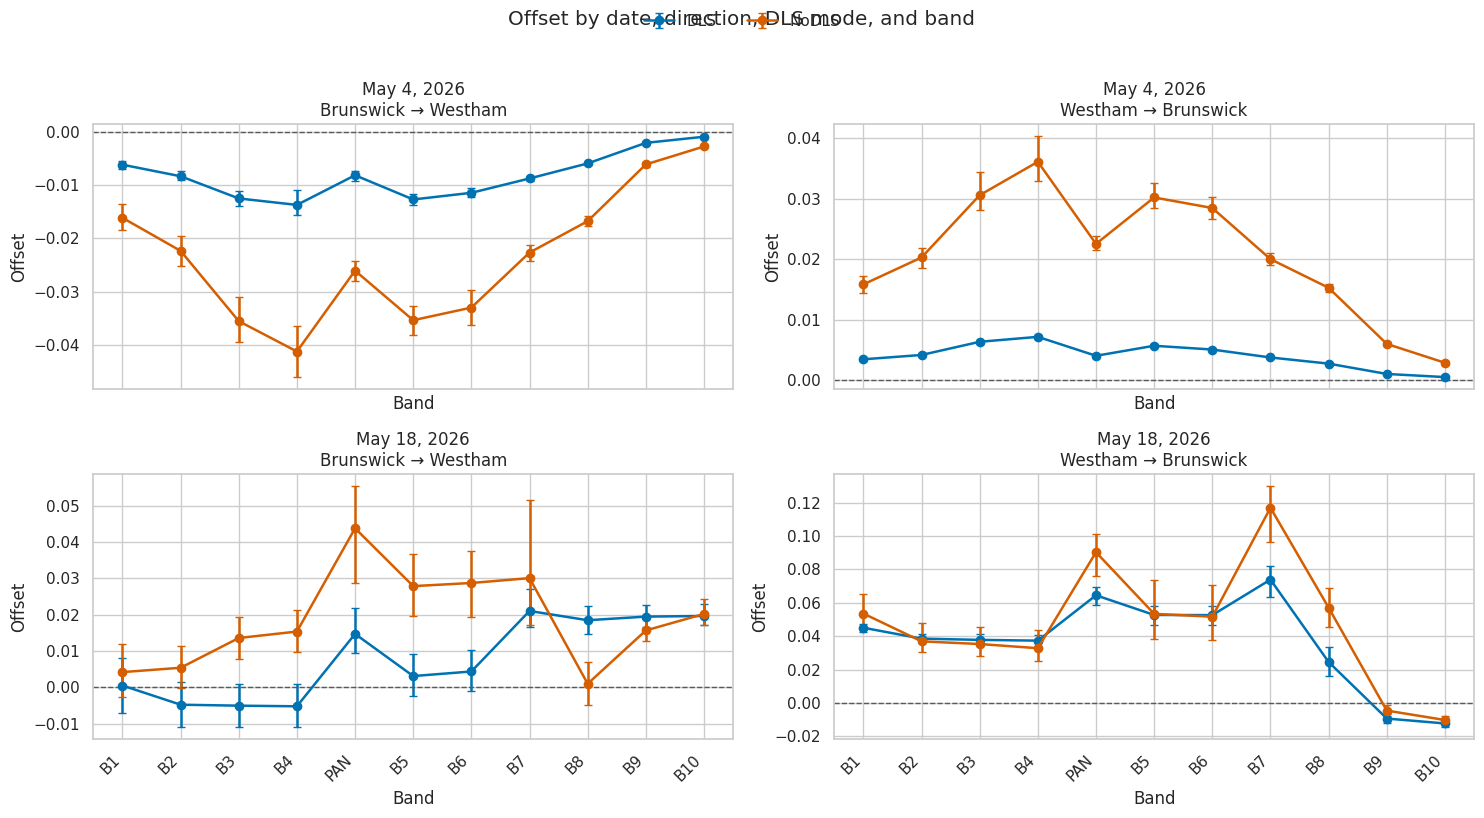

In [14]:
def plot_coefficient_profiles(frame, value, ci_low, ci_high, ylabel, stem):
    fig, axes = plt.subplots(
        nrows=len(DATES),
        ncols=len(DIRECTIONS),
        figsize=(15, 8),
        sharex=True,
        squeeze=False,
    )

    for row, flight_date in enumerate(DATES):
        for col, direction in enumerate(DIRECTIONS):
            ax = axes[row, col]

            subset = frame.loc[
                frame["flight_date"].eq(flight_date)
                & frame["direction"].eq(direction)
            ]

            for dls_mode in DLS_MODES:
                data = (
                    subset.loc[subset["dls_mode"].eq(dls_mode)]
                    .sort_values("band_index")
                )
                if data.empty:
                    continue

                x = data["band_index"].to_numpy()
                y = data[value].to_numpy()
                lower = y - data[ci_low].to_numpy()
                upper = data[ci_high].to_numpy() - y

                ax.errorbar(
                    x,
                    y,
                    yerr=np.vstack([lower, upper]),
                    marker="o",
                    linewidth=1.8,
                    capsize=3,
                    label=dls_mode,
                    color=DLS_PALETTE[dls_mode],
                )

            if value == "gain":
                ax.axhline(1.0, color="0.35", linestyle="--", linewidth=1)
            elif value == "offset":
                ax.axhline(0.0, color="0.35", linestyle="--", linewidth=1)

            ax.set_title(
                f"{DATE_LABELS.get(flight_date, flight_date)}\n"
                f"{DIRECTION_LABELS[direction]}"
            )
            ax.set_ylabel(ylabel)
            add_band_axis(ax)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(DLS_MODES),
        frameon=False,
    )
    fig.suptitle(ylabel + " by date, direction, DLS mode, and band", y=1.02)
    fig.tight_layout()
    save_figure(fig, stem)
    plt.show()


plot_coefficient_profiles(
    spatial_coefficients,
    value="gain",
    ci_low="gain_ci_low",
    ci_high="gain_ci_high",
    ylabel="Gain",
    stem="spatial_gain_profiles",
)

plot_coefficient_profiles(
    spatial_coefficients,
    value="offset",
    ci_low="offset_ci_low",
    ci_high="offset_ci_high",
    ylabel="Offset",
    stem="spatial_offset_profiles",
)

## 13. Gain versus offset

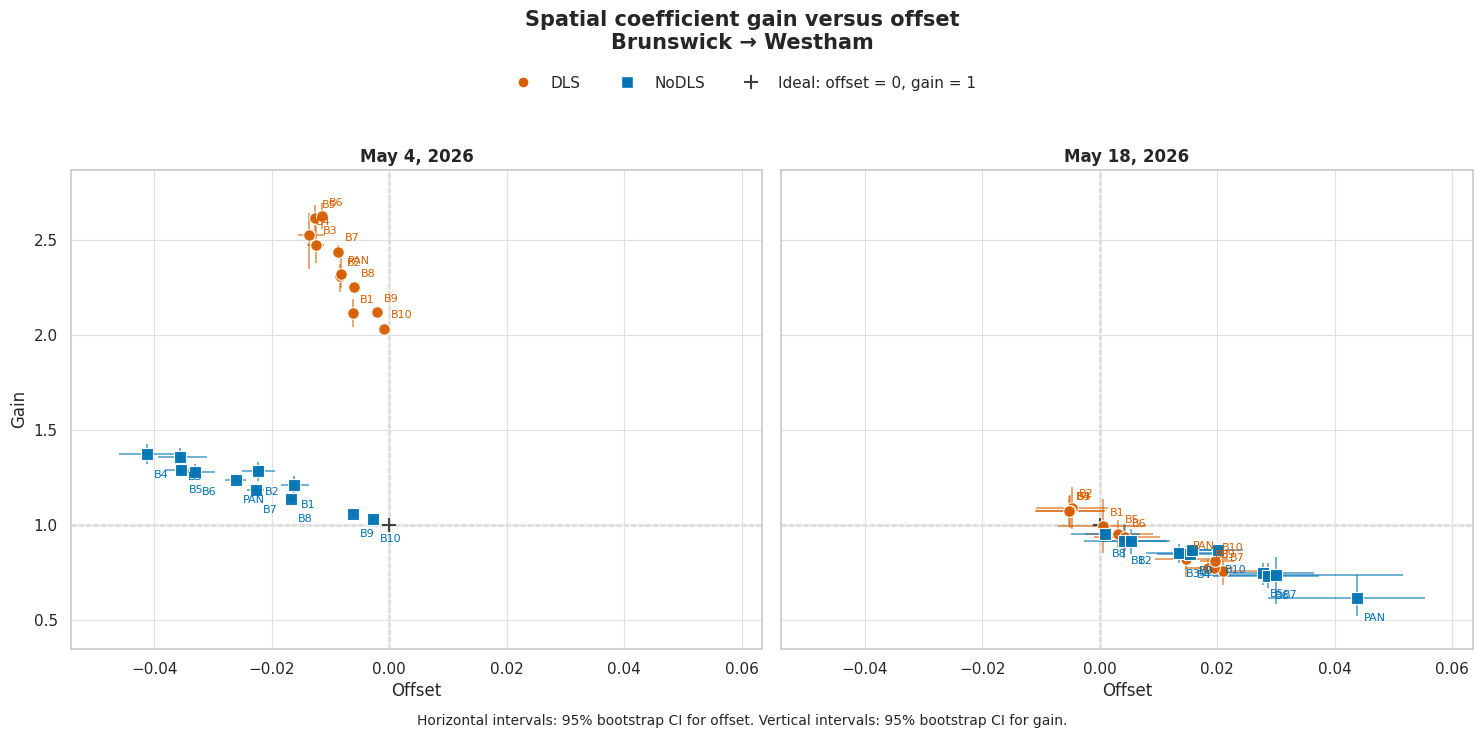

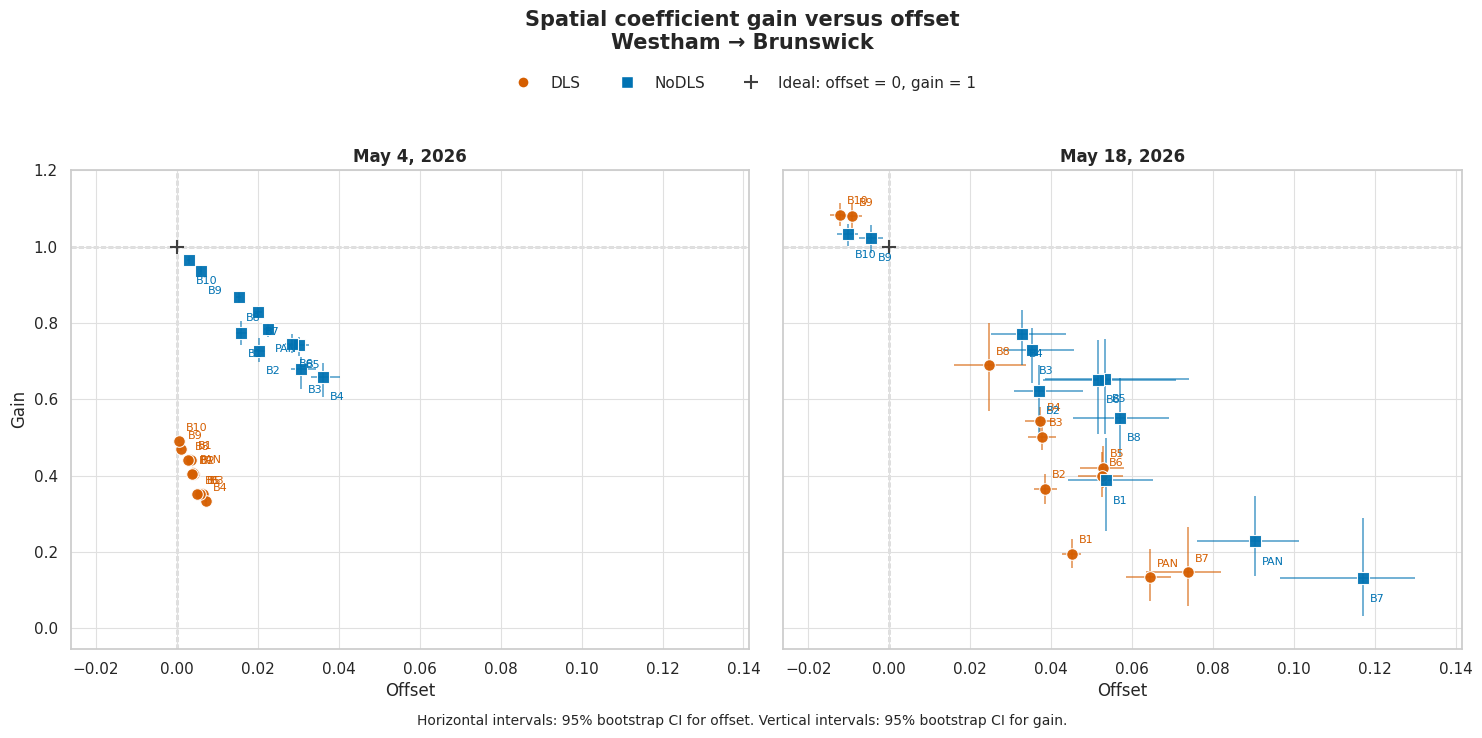

In [29]:
# ============================================================
# Section 13: gain versus offset with bootstrap uncertainty
# ============================================================

DLS_MARKERS = {
    "DLS": "o",
    "NoDLS": "s",
}

direction_order = [
    "brunswick_to_westham",
    "westham_to_brunswick",
]


def add_exact_uncertainty_bars(
    ax,
    data,
    *,
    color,
    linewidth=1.2,
    alpha=0.65,
):
    """
    Draw exact horizontal offset CIs and vertical gain CIs.

    Using hlines/vlines rather than ax.errorbar ensures that
    the plotted interval endpoints exactly equal the saved
    bootstrap CI bounds, even if a point estimate happens to
    fall outside a percentile interval.
    """

    # Horizontal lines: uncertainty in offset.
    ax.hlines(
        y=data["gain"],
        xmin=data["offset_ci_low"],
        xmax=data["offset_ci_high"],
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        zorder=1,
    )

    # Vertical lines: uncertainty in gain.
    ax.vlines(
        x=data["offset"],
        ymin=data["gain_ci_low"],
        ymax=data["gain_ci_high"],
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        zorder=1,
    )


for direction in direction_order:
    direction_data = (
        spatial_coefficients.loc[spatial_coefficients["direction"].eq(direction)]
        .copy()
        .sort_values(
            [
                "flight_date",
                "dls_mode",
                "band_index",
            ]
        )
    )

    if direction_data.empty:
        print(f"No coefficient data found for {direction}.")
        continue

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(DATES),
        figsize=(15, 6.5),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    axes = axes[0]

    for column_index, flight_date in enumerate(DATES):
        ax = axes[column_index]

        date_data = direction_data.loc[direction_data["flight_date"].eq(flight_date)]

        for dls_mode in DLS_MODES:
            data = (
                date_data.loc[date_data["dls_mode"].eq(dls_mode)]
                .sort_values("band_index")
                .copy()
            )

            if data.empty:
                continue

            color = DLS_PALETTE[dls_mode]
            marker = DLS_MARKERS[dls_mode]

            # Draw uncertainty intervals first so that the
            # fitted coefficient points appear above them.
            add_exact_uncertainty_bars(
                ax,
                data,
                color=color,
            )

            ax.scatter(
                data["offset"],
                data["gain"],
                s=70,
                marker=marker,
                color=color,
                edgecolor="white",
                linewidth=0.8,
                alpha=0.95,
                label=dls_mode,
                zorder=3,
            )

            # Put the DLS labels above the points and the
            # NoDLS labels below them to reduce overlap.
            annotation_y_offset = 6 if dls_mode == "DLS" else -11

            for _, record in data.iterrows():
                ax.annotate(
                    record["band_name"],
                    xy=(
                        record["offset"],
                        record["gain"],
                    ),
                    xytext=(
                        5,
                        annotation_y_offset,
                    ),
                    textcoords="offset points",
                    fontsize=8,
                    color=color,
                    ha="left",
                    va=("bottom" if annotation_y_offset > 0 else "top"),
                    zorder=4,
                )

        # Ideal/no-correction coefficient.
        ax.axvline(
            0.0,
            color="0.35",
            linestyle="--",
            linewidth=1.0,
            zorder=0,
        )

        ax.axhline(
            1.0,
            color="0.35",
            linestyle="--",
            linewidth=1.0,
            zorder=0,
        )

        # Mark the ideal coefficient location explicitly.
        ax.scatter(
            [0.0],
            [1.0],
            marker="+",
            s=100,
            linewidth=1.5,
            color="0.25",
            zorder=2,
        )

        ax.set_title(
            DATE_LABELS.get(
                flight_date,
                flight_date,
            ),
            fontsize=12,
            fontweight="bold",
        )

        ax.set_xlabel("Offset")
        ax.grid(
            True,
            color="0.88",
            linewidth=0.8,
        )
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Gain")

    # Use common limits between May 4 and May 18 for a given
    # direction. Include both point estimates and CI bounds.
    x_min = np.nanmin(
        direction_data[
            [
                "offset",
                "offset_ci_low",
                "offset_ci_high",
            ]
        ].to_numpy(dtype=float)
    )

    x_max = np.nanmax(
        direction_data[
            [
                "offset",
                "offset_ci_low",
                "offset_ci_high",
            ]
        ].to_numpy(dtype=float)
    )

    y_min = np.nanmin(
        direction_data[
            [
                "gain",
                "gain_ci_low",
                "gain_ci_high",
            ]
        ].to_numpy(dtype=float)
    )

    y_max = np.nanmax(
        direction_data[
            [
                "gain",
                "gain_ci_low",
                "gain_ci_high",
            ]
        ].to_numpy(dtype=float)
    )

    # Ensure that the ideal coefficient is visible.
    x_min = min(x_min, 0.0)
    x_max = max(x_max, 0.0)
    y_min = min(y_min, 1.0)
    y_max = max(y_max, 1.0)

    x_range = max(x_max - x_min, 1e-6)
    y_range = max(y_max - y_min, 1e-6)

    x_padding = 0.08 * x_range
    y_padding = 0.08 * y_range

    for ax in axes:
        ax.set_xlim(
            x_min - x_padding,
            x_max + x_padding,
        )
        ax.set_ylim(
            y_min - y_padding,
            y_max + y_padding,
        )

    # Remove duplicated legend entries from both subplots.
    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=DLS_MARKERS[dls_mode],
            color=DLS_PALETTE[dls_mode],
            markerfacecolor=DLS_PALETTE[dls_mode],
            markeredgecolor="white",
            linestyle="none",
            markersize=8,
            label=dls_mode,
        )
        for dls_mode in DLS_MODES
    ]

    ideal_handle = Line2D(
        [0],
        [0],
        marker="+",
        color="0.25",
        linestyle="none",
        markersize=10,
        markeredgewidth=1.5,
        label="Ideal: offset = 0, gain = 1",
    )

    fig.legend(
        handles=legend_handles + [ideal_handle],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=len(DLS_MODES) + 1,
        frameon=False,
    )

    direction_title = DIRECTION_LABELS.get(
        direction,
        direction,
    )

    fig.suptitle(
        (f"Spatial coefficient gain versus offset\n{direction_title}"),
        fontsize=15,
        fontweight="bold",
        y=1.09,
    )

    fig.text(
        0.5,
        -0.01,
        (
            "Horizontal intervals: 95% bootstrap CI for offset. "
            "Vertical intervals: 95% bootstrap CI for gain."
        ),
        ha="center",
        fontsize=10,
    )

    fig.tight_layout()

    save_figure(
        fig,
        f"spatial_gain_vs_offset_{direction}",
    )

    plt.show()


In [32]:
# fig, axes = plt.subplots(
#     nrows=len(DATES),
#     ncols=len(DIRECTIONS),
#     figsize=(15, 9),
#     squeeze=False,
# )

# for row, flight_date in enumerate(DATES):
#     for col, direction in enumerate(DIRECTIONS):
#         ax = axes[row, col]

#         subset = spatial_coefficients.loc[
#             spatial_coefficients["flight_date"].eq(flight_date)
#             & spatial_coefficients["direction"].eq(direction)
#         ].copy()

#         for dls_mode in DLS_MODES:
#             data = subset.loc[subset["dls_mode"].eq(dls_mode)]
#             if data.empty:
#                 continue

#             ax.scatter(
#                 data["gain"],
#                 data["offset"],
#                 s=65,
#                 alpha=0.85,
#                 color=DLS_PALETTE[dls_mode],
#                 label=dls_mode,
#             )

#             for _, record in data.iterrows():
#                 ax.annotate(
#                     record["band_name"],
#                     (record["gain"], record["offset"]),
#                     xytext=(4, 4),
#                     textcoords="offset points",
#                     fontsize=8,
#                 )

#         ax.axvline(1.0, color="0.35", linestyle="--", linewidth=1)
#         ax.axhline(0.0, color="0.35", linestyle="--", linewidth=1)
#         ax.set_xlabel("Gain")
#         ax.set_ylabel("Offset")
#         ax.set_title(
#             f"{DATE_LABELS.get(flight_date, flight_date)}\n"
#             f"{DIRECTION_LABELS[direction]}"
#         )

# handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(
#     handles,
#     labels,
#     loc="upper center",
#     ncol=len(DLS_MODES),
#     frameon=False,
# )
# fig.suptitle("Spatial coefficient gain versus offset", y=1.02)
# fig.tight_layout()
# save_figure(fig, "spatial_gain_vs_offset")
# plt.show()

## 14. Round-trip QA plots

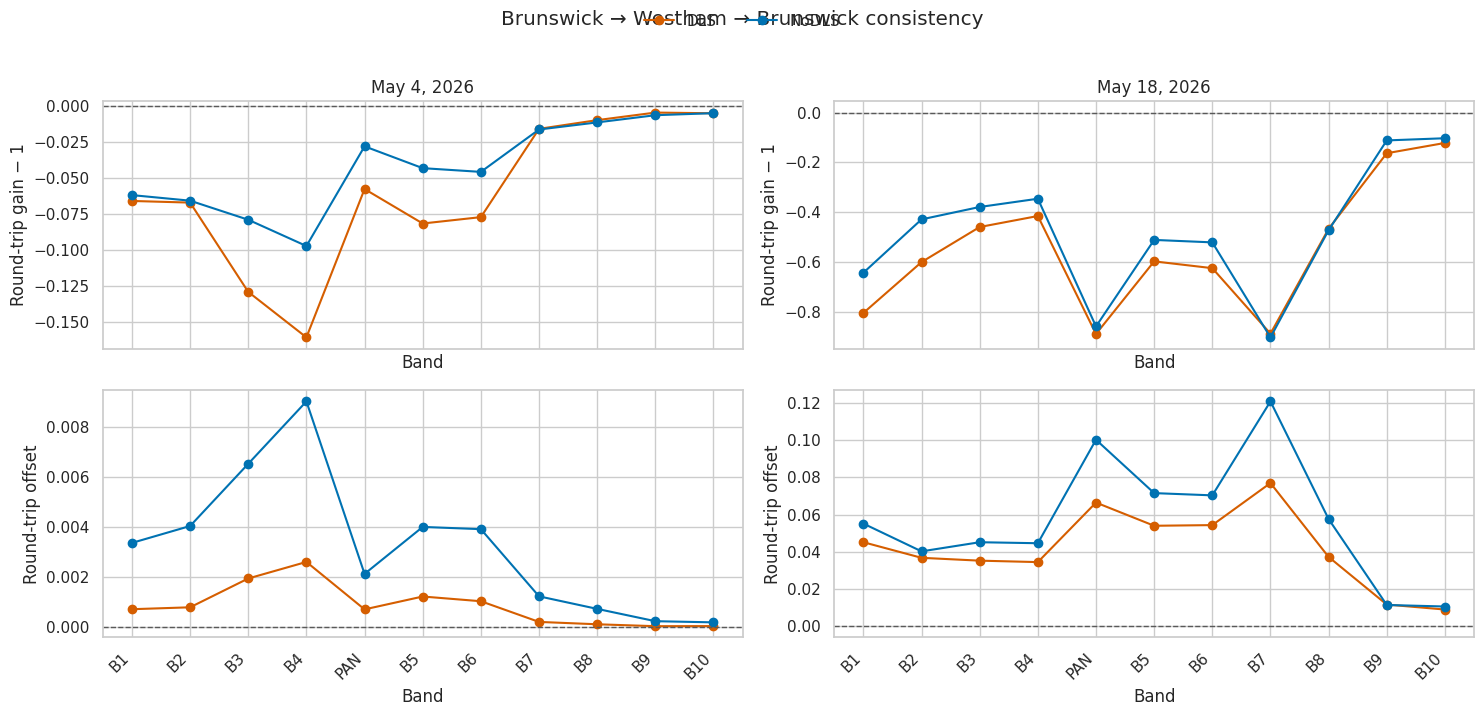

In [31]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=len(DATES),
    figsize=(15, 7),
    sharex=True,
    squeeze=False,
)

for col, flight_date in enumerate(DATES):
    subset = round_trip.loc[
        round_trip["flight_date"].eq(flight_date)
    ]

    for dls_mode in DLS_MODES:
        data = (
            subset.loc[subset["dls_mode"].eq(dls_mode)]
            .sort_values("band_index")
        )
        if data.empty:
            continue

        x = data["band_index"].to_numpy()

        axes[0, col].plot(
            x,
            data["round_trip_gain_error"],
            marker="o",
            label=dls_mode,
            color=DLS_PALETTE[dls_mode],
        )
        axes[1, col].plot(
            x,
            data["round_trip_offset_error"],
            marker="o",
            label=dls_mode,
            color=DLS_PALETTE[dls_mode],
        )

    axes[0, col].axhline(0.0, color="0.35", linestyle="--", linewidth=1)
    axes[1, col].axhline(0.0, color="0.35", linestyle="--", linewidth=1)

    axes[0, col].set_title(DATE_LABELS.get(flight_date, flight_date))
    axes[0, col].set_ylabel("Round-trip gain − 1")
    axes[1, col].set_ylabel("Round-trip offset")
    add_band_axis(axes[0, col])
    add_band_axis(axes[1, col])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(DLS_MODES),
    frameon=False,
)
fig.suptitle("Brunswick → Westham → Brunswick consistency", y=1.02)
fig.tight_layout()
save_figure(fig, "spatial_round_trip_diagnostics")
plt.show()

## 15. Compact review tables

In [18]:
coefficient_review_columns = [
    "flight_date",
    "dls_mode",
    "direction_label",
    "band_name",
    "gain",
    "gain_ci_low",
    "gain_ci_high",
    "offset",
    "offset_ci_low",
    "offset_ci_high",
    "r2",
    "rmse",
    "n",
    "bootstrap_success_fraction",
]

coefficient_review = spatial_coefficients.sort_values(
    [
        "flight_date",
        "dls_mode",
        "direction_label",
        "band_index",
    ]
)[coefficient_review_columns].reset_index(drop=True)


round_trip_review_columns = [
    "flight_date",
    "dls_mode",
    "band_name",
    "round_trip_gain",
    "round_trip_gain_error",
    "round_trip_offset",
    "wb_gain_minus_algebraic_inverse",
    "wb_offset_minus_algebraic_inverse",
]

round_trip_review = round_trip.sort_values(
    [
        "flight_date",
        "dls_mode",
        "band_index",
    ]
)[round_trip_review_columns].reset_index(drop=True)

display(coefficient_review)
display(round_trip_review)


,flight_date,dls_mode,direction_label,band_name,gain,gain_ci_low,gain_ci_high,offset,offset_ci_low,offset_ci_high,r2,rmse,n,bootstrap_success_fraction
0,2026-05-04,DLS,Brunswick → Westham,B1,2.114857,2.044310,2.187889,-0.006202,-0.006942,-0.005480,0.932768,0.001274,500,1.0
1,2026-05-04,DLS,Brunswick → Westham,B2,2.309573,2.223228,2.370699,-0.008369,-0.009045,-0.007410,0.920367,0.001297,500,1.0
2,2026-05-04,DLS,Brunswick → Westham,B3,2.474582,2.375975,2.573061,-0.012530,-0.013961,-0.011102,0.848961,0.001766,500,1.0
3,2026-05-04,DLS,Brunswick → Westham,B4,2.524686,2.344534,2.640773,-0.013741,-0.015556,-0.010983,0.798781,0.001992,500,1.0
4,2026-05-04,DLS,Brunswick → Westham,PAN,2.318646,2.248004,2.405913,-0.008181,-0.009179,-0.007365,0.952628,0.001560,500,1.0
5,2026-05-04,DLS,Brunswick → Westham,B5,2.612838,2.544317,2.682466,-0.012723,-0.013700,-0.011760,0.884793,0.002044,500,1.0
6,2026-05-04,DLS,Brunswick → Westham,B6,2.624251,2.558526,2.693074,-0.011473,-0.012312,-0.010651,0.896295,0.001735,500,1.0
7,2026-05-04,DLS,Brunswick → Westham,B7,2.437036,2.400146,2.471633,-0.008783,-0.009187,-0.008358,0.982242,0.001339,500,1.0
8,2026-05-04,DLS,Brunswick → Westham,B8,2.249519,2.224313,2.276031,-0.005964,-0.006207,-0.005721,0.988696,0.001286,500,1.0
9,2026-05-04,DLS,Brunswick → Westham,B9,2.118759,2.097173,2.140551,-0.002110,-0.002201,-0.002006,0.994405,0.001148,500,1.0


,flight_date,dls_mode,band_name,round_trip_gain,round_trip_gain_error,round_trip_offset,wb_gain_minus_algebraic_inverse,wb_offset_minus_algebraic_inverse
0,2026-05-04,DLS,B1,0.934056,-0.065944,0.000704,-0.031181,0.000511
1,2026-05-04,DLS,B2,0.932911,-0.067089,0.000780,-0.029048,0.000537
2,2026-05-04,DLS,B3,0.870938,-0.129062,0.001931,-0.052155,0.001278
3,2026-05-04,DLS,B4,0.839398,-0.160602,0.002592,-0.063612,0.001718
4,2026-05-04,DLS,PAN,0.942322,-0.057678,0.000697,-0.024876,0.000494
5,2026-05-04,DLS,B5,0.918410,-0.081590,0.001211,-0.031227,0.000814
6,2026-05-04,DLS,B6,0.922834,-0.077166,0.001023,-0.029405,0.000685
7,2026-05-04,DLS,B7,0.984096,-0.015904,0.000196,-0.006526,0.000139
8,2026-05-04,DLS,B8,0.990141,-0.009859,0.000102,-0.004383,0.000076
9,2026-05-04,DLS,B9,0.995389,-0.004611,0.000026,-0.002176,0.000021


## 16. Example: retrieve and apply saved coefficients

The lookup key is:

`flight_date + dls_mode + direction + band_name`

Always apply the stored equation exactly as documented:

`destination = gain * source + offset`

In [19]:
def get_coefficient(
    coefficient_table,
    *,
    flight_date,
    dls_mode,
    direction,
    band_name,
):
    match = coefficient_table.loc[
        coefficient_table["flight_date"].eq(flight_date)
        & coefficient_table["dls_mode"].eq(dls_mode)
        & coefficient_table["direction"].eq(direction)
        & coefficient_table["band_name"].eq(band_name)
    ]

    if len(match) != 1:
        raise KeyError(
            "Expected exactly one coefficient row; "
            f"found {len(match)}."
        )

    return match.iloc[0]


example = get_coefficient(
    spatial_coefficients,
    flight_date="2026-05-04",
    dls_mode="DLS",
    direction="brunswick_to_westham",
    band_name="B4",
)

source_values = np.array([0.01, 0.02, 0.03])
destination_values = (
    example["gain"] * source_values + example["offset"]
)

print(example[[
    "equation", "gain", "offset",
    "gain_ci_low", "gain_ci_high",
    "offset_ci_low", "offset_ci_high",
]])
print("Source:", source_values)
print("Transformed destination:", destination_values)

equation          destination = gain * source + offset
gain                                          2.524686
offset                                       -0.013741
gain_ci_low                                   2.344534
gain_ci_high                                  2.640773
offset_ci_low                                -0.015556
offset_ci_high                               -0.010983
Name: 3, dtype: object
Source: [0.01 0.02 0.03]
Transformed destination: [0.01150546 0.03675232 0.06199918]
